# 题目: 构建和使用长短时记忆神经网络（LSTM） - 使用 airline-passengers 数据集

在这个教程中，我们将介绍如何使用 Pytorch 构建和训练一个长短时记忆神经网络（LSTM）模型，然后使用该模型预测未来的乘客数量。我们将使用 [airline-passengers 数据集](https://www.kaggle.com/rakannimer/air-passengers)。

## 1. 加载数据

使用 pandas 加载数据集，并通过 matplotlib 可视化数据。

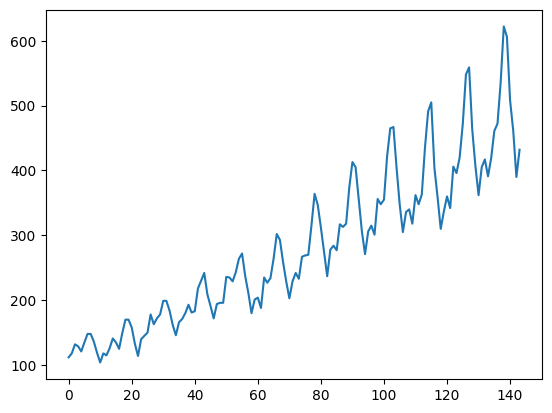

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('airline-passengers.csv')
timeseries = df[["Passengers"]].values.astype('float32')

plt.plot(timeseries)
plt.show()

* 时序数据归一化

对于时序数据，归一化对模型性能的影响至关重要。我们将使用 MinMaxScaler 对时序数据进行归一化，以便更好地训练 LSTM 模型。

In [2]:
from sklearn.preprocessing import MinMaxScaler

# normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
timeseries = scaler.fit_transform(timeseries)

## 2. 划分训练集和测试集

我们将数据集划分为训练集和测试集。我们将使用前三分之二的数据作为训练集，剩余的数据作为测试集。

注意：对时序数据而言，划分训练集和测试集时，不能随机划分。我们需要确保训练集中的数据是按时间顺序排列的，以防止模型在训练时“看到”未来的数据。

In [3]:
# train-test split for time series
train_size = int(len(timeseries) * 0.67)
test_size = len(timeseries) - train_size
train, test = timeseries[:train_size], timeseries[train_size:]

* 创建 Dataset

对于训练集和测试集中的数据，我们采用步长为 lookback 的时间窗口，去预测下一时刻的目标值，以此构建样本。

In [4]:
import torch
import numpy as np

def create_dataset(dataset, lookback):
    """Transform a time series into a prediction dataset
    
    Args:
        dataset: A numpy array of time series, first dimension is the time steps
        lookback: Size of window for prediction
    """
    X, y = [], []
    for i in range(len(dataset) - lookback):
        feature = dataset[i : i + lookback, 0]  # 从i到i+lookback，共lookback个数据
        target = dataset[i + lookback, 0]  # 第i+lookback个数据
        X.append(feature)
        y.append(target)
    X, y = np.array(X), np.array(y)  # X.shape: (samples, lookback), y.shape: (samples,)
    X = X.reshape(X.shape[0], X.shape[1], 1)  # shape: (samples, lookback, features)，添加一个维度，LSTM 需要接受三维输入
    return torch.tensor(X), torch.tensor(y)

In [5]:
lookback = 5
X_train, y_train = create_dataset(train, lookback=lookback)
X_test, y_test = create_dataset(test, lookback=lookback)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([91, 5, 1]) torch.Size([91])
torch.Size([43, 5, 1]) torch.Size([43])


In [6]:
from torch.utils.data import DataLoader, Dataset

class AirDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return len(self.X)

## 3. 构建模型

我们将构建一个包含两个 LSTM 层和一个全连接层的模型。

* LSTM 层的参数

    * input_size: 输入特征的数量
    * hidden_size: 隐藏层的大小
    * num_layers: LSTM 层的数量
    * batch_first: 如果为 True，则输入和输出张量的形状为 (batch_size, sequence_length, input_size)，否则输入和输出张量的形状为 (sequence_length, batch_size, input_size)
    * dropout: dropout 概率（要求 num_layers > 1）
    * bidirectional: 是否使用双向 LSTM（输出维度将变为 hidden_size * 2）

* 我们采用 batch_first 策略，LSTM 层接受的数据格式为 (batch_size, sequence_length, input_size)

* LSTM 层的输出是一个元祖，包含了输出张量和最后一个时间步的 hidden state 和 cell state

* 我们将最后一个 LSTM 层的最后一个时间步的输出传递给全连接层，以预测下一个时间步的乘客数量。

In [7]:
import torch.nn as nn

class AirModel(nn.Module):
    def __init__(self):
        super(AirModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size=1,
                            hidden_size=8,
                            num_layers=1,
                            batch_first=True,
                            bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=16,
                            hidden_size=32,
                            num_layers=1,
                            batch_first=True,
                            bidirectional=False)
        self.linear = nn.Linear(32, 1)
    def forward(self, x):  # x.shape: (batch, lookback, 1)
        x, _ = self.lstm1(x)  # x.shape: (batch, lookback, 16)
        x, _ = self.lstm2(x)  # x.shape: (batch, lookback, 32)
        # extract only the last time step
        x = x[:, -1, :]  # x.shape: (batch, 32)
        x = self.linear(x)  # x.shape: (batch, 1)
        return x

## 4. 训练模型

In [8]:
device = "cpu"

model = AirModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # 时序数据通常使用 Adam 优化器
loss_fn = nn.MSELoss()
train_dataset = AirDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=8)

n_epochs = 100
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred.flatten(), y_batch)  # 计算 MSE 损失, y_pred 的尺寸是 (batch, 1), y_batch 的尺寸是 (batch,)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Validation
    if epoch % 10 == 0:
        model.eval()
        with torch.no_grad():
            y_pred = model(X_train)
            train_rmse = np.sqrt(loss_fn(y_pred.flatten(), y_train))  # 计算 RMSE 损失, y_pred 的尺寸是 (samples, 1), y_train 的尺寸是 (samples,)
            y_pred = model(X_test)
            test_rmse = np.sqrt(loss_fn(y_pred.flatten(), y_test))
        print("Epoch %d: train RMSE %.4f, test RMSE %.4f" % (epoch, train_rmse, test_rmse))

Epoch 0: train RMSE 0.1327, test RMSE 0.4246
Epoch 10: train RMSE 0.0607, test RMSE 0.1539
Epoch 20: train RMSE 0.0502, test RMSE 0.1479
Epoch 30: train RMSE 0.0454, test RMSE 0.0997
Epoch 40: train RMSE 0.0420, test RMSE 0.1078
Epoch 50: train RMSE 0.0514, test RMSE 0.1024
Epoch 60: train RMSE 0.0396, test RMSE 0.1082
Epoch 70: train RMSE 0.0437, test RMSE 0.1076
Epoch 80: train RMSE 0.0384, test RMSE 0.1071
Epoch 90: train RMSE 0.0396, test RMSE 0.1053


## 5. 模型预测结果可视化

思考：时序预测模型的预测结果通常会表现出相对于真实值的滞后性，思考其中的原因？

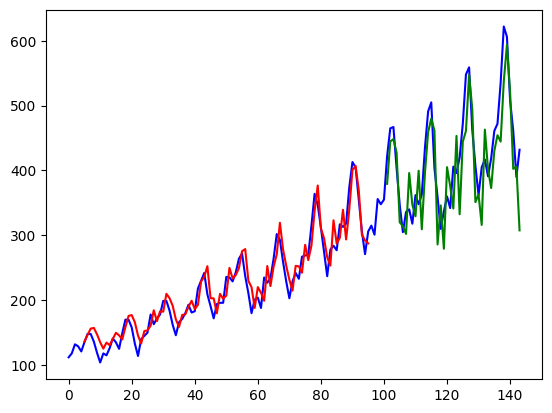

In [9]:
with torch.no_grad():
    # shift train predictions for plotting
    train_plot = np.ones_like(timeseries) * np.nan
    y_pred_train = model(X_train)
    y_pred_train = scaler.inverse_transform(y_pred_train)  # 反归一化
    train_plot[lookback:train_size] = y_pred_train
    # shift test predictions for plotting
    test_plot = np.ones_like(timeseries) * np.nan
    y_pred_test = model(X_test)
    y_pred_test = scaler.inverse_transform(y_pred_test)  # 反归一化
    test_plot[train_size+lookback:len(timeseries)] = y_pred_test

plt.plot(scaler.inverse_transform(timeseries), c='b')
plt.plot(train_plot, c='r')
plt.plot(test_plot, c='g')
plt.show()

# 作业

#### 构建简单的LSTM网络模型，使用德里市每日气候数据集进行训练和测试。介绍所构建的模型，并报告在测试集上的准确率。

daily-climate: https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data

德里市每日气候数据集任务：使用当天及以前（0~t时刻）的湿度、气压、风速三个指标预测当天（t时刻）的温度，最后报告测试集上温度值的均方误差MSE。

Selected Features (all 14): ['meantemp_lag_1', 'meantemp_lag_3', 'meantemp_lag_7', 'meantemp_roll7', 'meantemp_roll_std7', 'humidity', 'humidity_roll7', 'wind_speed', 'wind_speed_roll7', 'meanpressure_roll7', 'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos']
Training set shape: X_train=(1448, 14, 14), y_train=(1448,)
Test set shape: X_test=(100, 14, 14), y_test=(100,)
Epoch 1/60
41/41 [==============================] - 6s 45ms/step - loss: 0.3412 - val_loss: 0.2404 - lr: 0.0010
Epoch 2/60
41/41 [==============================] - 1s 22ms/step - loss: 0.1425 - val_loss: 0.1704 - lr: 0.0010
Epoch 3/60
41/41 [==============================] - 1s 24ms/step - loss: 0.1112 - val_loss: 0.1241 - lr: 0.0010
Epoch 4/60
41/41 [==============================] - 1s 22ms/step - loss: 0.0984 - val_loss: 0.0633 - lr: 0.0010
Epoch 5/60
41/41 [==============================] - 1s 24ms/step - loss: 0.0735 - val_loss: 0.0491 - lr: 0.0010
Epoch 6/60
41/41 [==============================] - 1s 23ms/ste

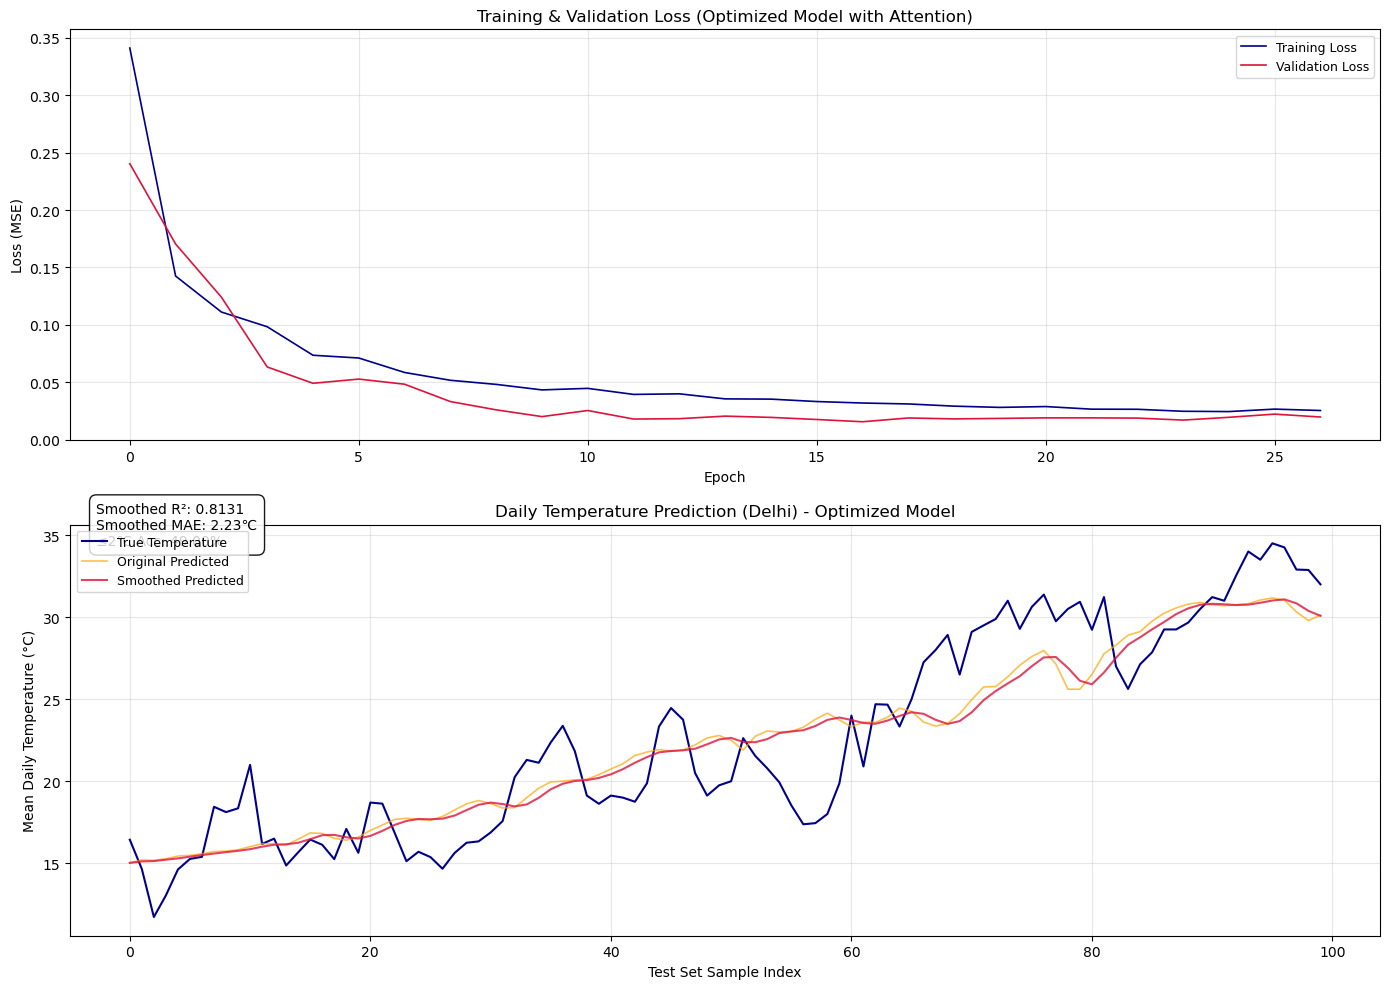

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional, Permute, Reshape, Multiply, Lambda, Layer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import L2
from tensorflow.keras import backend as K

# ===================== 1. 自定义注意力层（修复核心：继承Layer类） =====================
class AttentionLayer(Layer):
    def __init__(self, time_step, **kwargs):
        self.time_step = time_step
        super(AttentionLayer, self).__init__(**kwargs)
    
    def build(self, input_shape):
        # 定义可训练的权重（注意力权重）
        self.dense = Dense(1, activation='tanh')
        super(AttentionLayer, self).build(input_shape)
    
    def call(self, inputs):
        # inputs shape: (batch_size, time_steps, units)
        attention_weights = self.dense(inputs)  # (batch_size, time_step, 1)
        attention_weights = Reshape((self.time_step,))(attention_weights)  # (batch_size, time_step)
        attention_weights = K.softmax(attention_weights)  # 归一化权重
        attention_weights = Permute((2, 1))(Reshape((1, self.time_step))(attention_weights))  # (batch_size, 1, time_step)
        weighted_input = Multiply()([inputs, attention_weights])  # (batch_size, time_step, units)
        weighted_sum = Lambda(lambda x: K.sum(x, axis=1))(weighted_input)  # (batch_size, units)
        return weighted_sum
    
    def compute_output_shape(self, input_shape):
        # 返回输出形状：(batch_size, units)
        return (input_shape[0], input_shape[2])

# ===================== 2. 增强版数据预处理 + 核心特征工程 =====================
# 加载数据
train_df = pd.read_csv('DailyDelhiClimateTrain.csv')
test_df = pd.read_csv('DailyDelhiClimateTest.csv')

# 日期处理+排序
train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])
train_df = train_df.sort_values('date').reset_index(drop=True)
test_df = test_df.sort_values('date').reset_index(drop=True)

# 优化1：新增温度滞后特征（核心！温度自身的历史值是最强预测因子）
def add_temp_lag_features(df):
    df_new = df.copy()
    # 加入前1/3/7天的温度（滞后特征）
    for lag in [1, 3, 7]:
        df_new[f'meantemp_lag_{lag}'] = df_new['meantemp'].shift(lag)
    # 填充滞后特征的空值（用前向填充+中位数兜底）
    df_new.fillna(method='ffill', inplace=True)
    df_new.fillna(df_new['meantemp'].median(), inplace=True)
    return df_new

train_df = add_temp_lag_features(train_df)
test_df = add_temp_lag_features(test_df)

# 优化2：时间特征工程（保留核心循环特征，简化冗余）
def add_time_features(df):
    df_new = df.copy()
    df_new['month'] = df_new['date'].dt.month
    df_new['weekday'] = df_new['date'].dt.weekday
    # 仅保留核心循环编码（移除season冗余特征）
    df_new['month_sin'] = np.sin(2 * np.pi * df_new['month'] / 12)
    df_new['month_cos'] = np.cos(2 * np.pi * df_new['month'] / 12)
    df_new['weekday_sin'] = np.sin(2 * np.pi * df_new['weekday'] / 7)
    df_new['weekday_cos'] = np.cos(2 * np.pi * df_new['weekday'] / 7)
    return df_new

train_df = add_time_features(train_df)
test_df = add_time_features(test_df)

# 优化3：温和异常值处理（仅替换极端异常值）
def handle_outliers_mild(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 2.0 * IQR  # 放宽异常值阈值，仅处理极端值
        upper = Q3 + 2.0 * IQR
        median = df_clean[col].median()
        df_clean.loc[df_clean[col] < lower, col] = median
        df_clean.loc[df_clean[col] > upper, col] = median
    return df_clean

numeric_cols = ['meantemp', 'humidity', 'wind_speed', 'meanpressure'] + [f'meantemp_lag_{lag}' for lag in [1,3,7]]
train_df = handle_outliers_mild(train_df, numeric_cols)
test_df = handle_outliers_mild(test_df, numeric_cols)

# 优化4：多尺度滚动特征（仅保留核心，减少冗余）
def add_core_rolling_features(df):
    df_new = df.copy()
    for col in ['humidity', 'wind_speed', 'meanpressure', 'meantemp']:
        df_new[f'{col}_roll7'] = df_new[col].rolling(window=7, min_periods=1).mean()
        df_new[f'{col}_roll_std7'] = df_new[col].rolling(window=7, min_periods=1).std().fillna(0)
    return df_new

train_df = add_core_rolling_features(train_df)
test_df = add_core_rolling_features(test_df)

# 优化5：特征筛选（保留全部14个候选特征）
features_candidate = [
    # 温度核心特征
    'meantemp_lag_1', 'meantemp_lag_3', 'meantemp_lag_7', 'meantemp_roll7', 'meantemp_roll_std7',
    # 气象特征
    'humidity', 'humidity_roll7', 'wind_speed', 'wind_speed_roll7', 'meanpressure_roll7',
    # 时间循环特征
    'month_sin', 'month_cos', 'weekday_sin', 'weekday_cos'
]
target = 'meantemp'

# 特征重要性筛选（k='all'保留全部14个特征）
selector = SelectKBest(f_regression, k='all')
X_train_selector = selector.fit_transform(train_df[features_candidate], train_df[target])
X_test_selector = selector.transform(test_df[features_candidate])
# 获取筛选后的特征名
selected_features = [features_candidate[i] for i in selector.get_support(indices=True)]
print(f"Selected Features (all 14): {selected_features}")

# 特征/目标分开归一化
scaler_features = MinMaxScaler(feature_range=(0, 1))
train_features_scaled = scaler_features.fit_transform(train_df[selected_features])
test_features_scaled = scaler_features.transform(test_df[selected_features])

scaler_target = MinMaxScaler(feature_range=(0, 1))
train_target_scaled = scaler_target.fit_transform(train_df[[target]])
test_target_scaled = scaler_target.transform(test_df[[target]])

# 优化6：调整时间步长为14（更贴合周度温度趋势）
time_step = 14
def create_sequences_optimized(features_scaled, target_scaled):
    X, y = [], []
    for i in range(time_step, len(features_scaled)):
        X.append(features_scaled[i-time_step:i, :])
        y.append(target_scaled[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences_optimized(train_features_scaled, train_target_scaled)
X_test, y_test = create_sequences_optimized(test_features_scaled, test_target_scaled)

print(f"Training set shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Test set shape: X_test={X_test.shape}, y_test={y_test.shape}")

# ===================== 3. 模型升级：双向LSTM + 自定义注意力层 =====================
# 学习率策略（更平缓的调度）
def lr_scheduler_optimized(epoch, lr):
    if epoch < 25:
        return 0.001  # 延长固定学习率周期
    elif epoch < 40:
        return lr * 0.95  # 更平缓降低
    else:
        return lr * 0.9  # 最后10epoch加速降低

# 回调函数优化
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.7, patience=6, min_lr=1e-5, verbose=0
)
early_stopping = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1
)  # 早停+恢复最优权重，防止过拟合

# 构建带注意力的双向LSTM模型（核心修复：使用自定义AttentionLayer实例）
model = Sequential([
    # 第一层双向LSTM（增加神经元数到100，提升拟合能力）
    Bidirectional(LSTM(
        100, return_sequences=True, 
        kernel_regularizer=L2(5e-5),  # 降低正则化系数，平衡拟合与泛化
        recurrent_regularizer=L2(1e-5)
    ), input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.2),  # 降低Dropout率，保留更多特征
    
    # 注意力层（核心修复：实例化自定义Layer类）
    AttentionLayer(time_step=time_step),
    
    # 全连接层（简化结构，减少冗余）
    Dense(64, activation='relu', kernel_regularizer=L2(5e-5)),
    BatchNormalization(),
    Dropout(0.15),
    Dense(32, activation='relu', kernel_regularizer=L2(5e-5)),
    Dense(1)
])

# 编译模型（优化器参数微调）
optimizer = Adam(learning_rate=0.001, decay=5e-6)  # 降低权重衰减
model.compile(optimizer=optimizer, loss='mse')

# 训练策略优化
history = model.fit(
    X_train, y_train,
    batch_size=32,  # 减小batch_size，提升梯度更新频率
    epochs=60,  # 延长训练周期，配合早停
    validation_split=0.1,  # 降低验证集比例，增加训练数据
    callbacks=[LearningRateScheduler(lr_scheduler_optimized), reduce_lr, early_stopping],
    verbose=1
)

# ===================== 4. 评估 + 预测结果后处理 =====================
y_pred_scaled = model.predict(X_test, verbose=0)

# 反归一化
y_test_original = scaler_target.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_pred_original = scaler_target.inverse_transform(y_pred_scaled).flatten()

# 后处理：预测结果平滑（3步移动平均，减少波动）
y_pred_smoothed = pd.Series(y_pred_original).rolling(window=3, min_periods=1).mean().values

# 计算评估指标（对比原始预测和平滑后结果）
def calculate_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100
    acc1 = np.sum(np.abs(y_true - y_pred) <= 1) / len(y_true) * 100
    acc15 = np.sum(np.abs(y_true - y_pred) <= 1.5) / len(y_true) * 100
    acc2 = np.sum(np.abs(y_true - y_pred) <= 2) / len(y_true) * 100
    return mse, mae, r2, mape, acc1, acc15, acc2

# 原始预测指标
mse_org, mae_org, r2_org, mape_org, acc1_org, acc15_org, acc2_org = calculate_metrics(y_test_original, y_pred_original)
# 平滑后预测指标
mse_smo, mae_smo, r2_smo, mape_smo, acc1_smo, acc15_smo, acc2_smo = calculate_metrics(y_test_original, y_pred_smoothed)

# 输出结果
print("\n===== Original Prediction Results =====")
print(f"MSE: {mse_org:.4f}, MAE: {mae_org:.4f}℃, R²: {r2_org:.4f}, MAPE: {mape_org:.2f}%")
print(f"≤1℃准确率: {acc1_org:.2f}%, ≤1.5℃准确率: {acc15_org:.2f}%, ≤2℃准确率: {acc2_org:.2f}%")

print("\n===== Smoothed Prediction Results =====")
print(f"MSE: {mse_smo:.4f}, MAE: {mae_smo:.4f}℃, R²: {r2_smo:.4f}, MAPE: {mape_smo:.2f}%")
print(f"≤1℃准确率: {acc1_smo:.2f}%, ≤1.5℃准确率: {acc15_smo:.2f}%, ≤2℃准确率: {acc2_smo:.2f}%")

# 可视化
plt.figure(figsize=(14, 10))

# 子图1：训练/验证损失
plt.subplot(2, 1, 1)
plt.plot(history.history['loss'], label='Training Loss', color='darkblue', linewidth=1.2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='crimson', linewidth=1.2)
plt.title('Training & Validation Loss (Optimized Model with Attention)', fontsize=12)
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss (MSE)', fontsize=10)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

# 子图2：真实值 vs 原始预测 vs 平滑预测
plt.subplot(2, 1, 2)
plt.plot(y_test_original, label='True Temperature', color='darkblue', linewidth=1.5)
plt.plot(y_pred_original, label='Original Predicted', color='orange', linewidth=1.2, alpha=0.7)
plt.plot(y_pred_smoothed, label='Smoothed Predicted', color='crimson', linewidth=1.5, alpha=0.8)
plt.text(0.02, 0.95, 
         f'Smoothed R²: {r2_smo:.4f}\nSmoothed MAE: {mae_smo:.2f}℃\n≤2℃ Acc: {acc2_smo:.2f}%', 
         transform=plt.gca().transAxes, 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9),
         fontsize=10)
plt.title('Daily Temperature Prediction (Delhi) - Optimized Model', fontsize=12)
plt.xlabel('Test Set Sample Index', fontsize=10)
plt.ylabel('Mean Daily Temperature (°C)', fontsize=10)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()